<a href="https://colab.research.google.com/github/Siddwayy/data-visualization-projects/blob/main/4304_Infographics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✓  watermark loaded (50,676 bytes)
✓  Placed 12 watermarks
✓  header bird loaded (103,365 bytes)
⏳  Downloading Natural Earth shapefile …
✓  Loaded NL boundary (1 features)
✓  branch loaded (98,550 bytes)
✓  Placed branch images (h=0.0700)


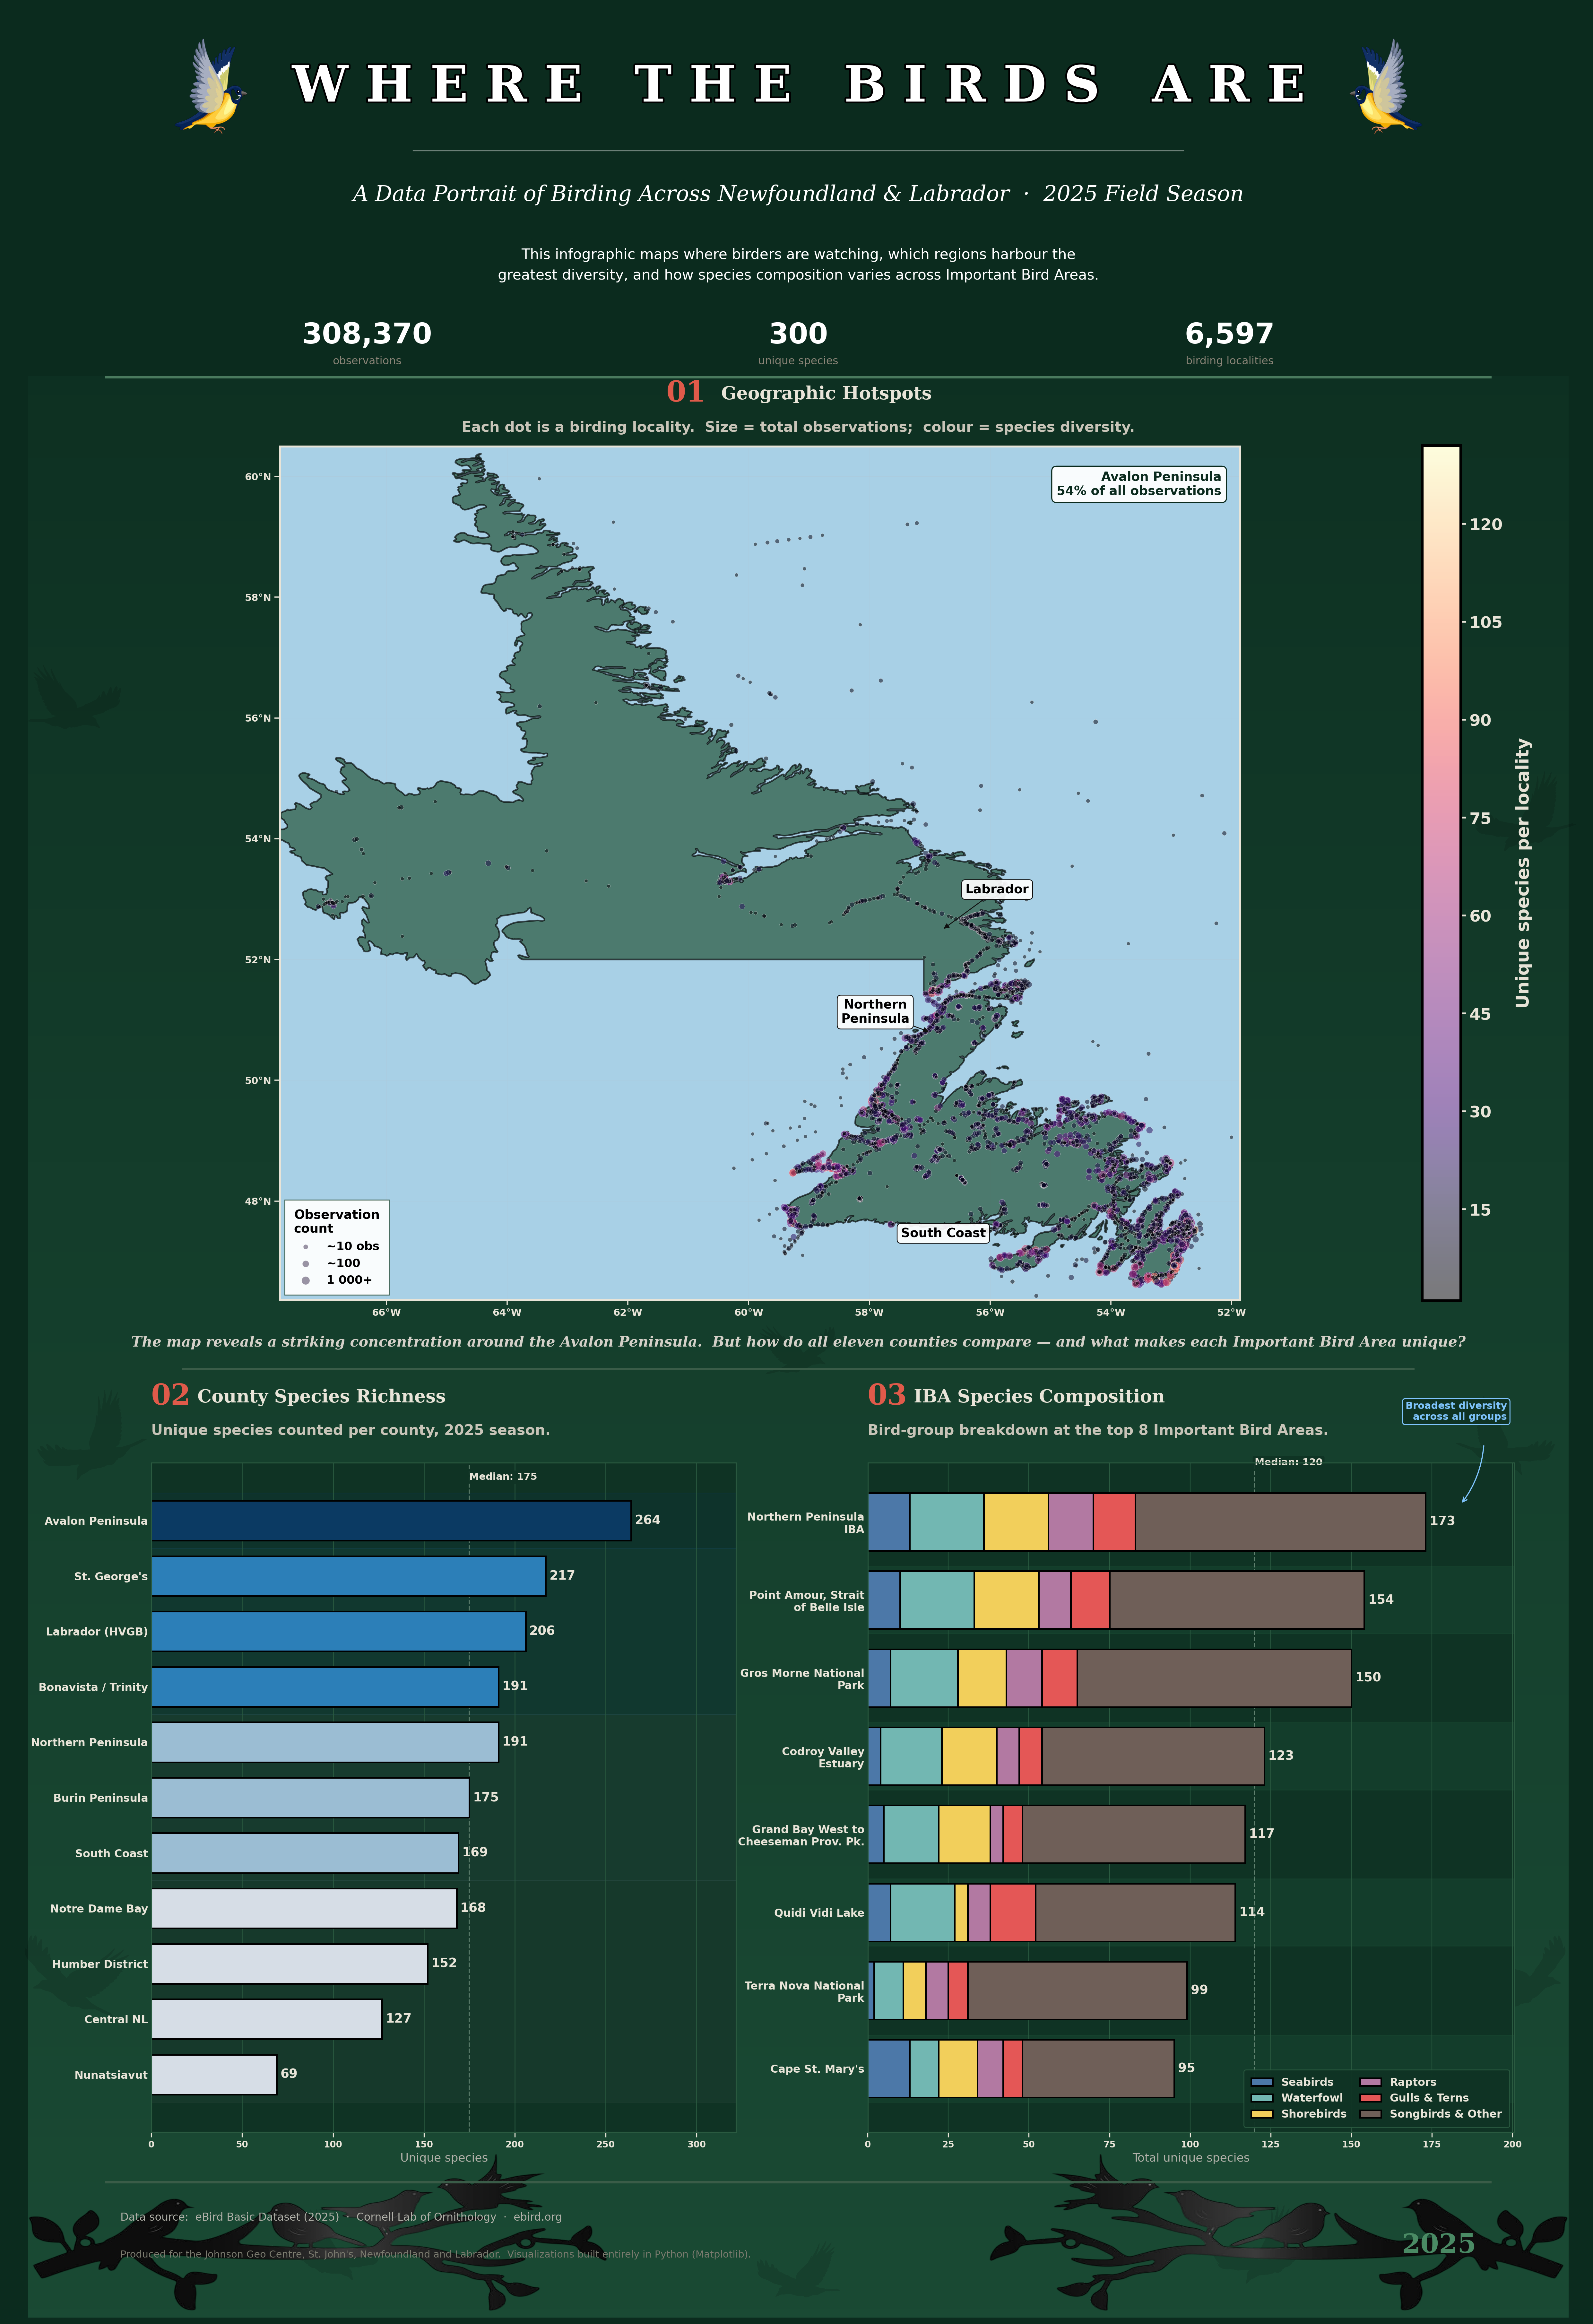

✓ Saved infographic.png  (24×36 in @ 200 dpi)


In [17]:
# Newfoundland & Labrador Birding Infographic — Johnson Geo Centre
# 24×36 inch poster · 3 visualizations · Single Jupyter cell

from pathlib import Path
import re, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image as PILImage
import requests

warnings.filterwarnings("ignore")

# ── Config ──
ROOT = Path(".")

# Background gradient
BG_TOP  = "#0b2b1e"
BG_MID  = "#143d2b"
BG_BOT  = "#1a4a34"

# Core palette
DARK_GRN = "#0b2b1e"
MID_GRN  = "#1b4d2e"
OCEAN    = "#a8d0e6"
RULE_CLR = "#3a5c48"
ACCENT   = "#e05a4a"

# Bar tier colors
LEADER = "#0b3a63"
HIGH   = "#2c7fb8"
MID_T  = "#9bbdd3"
LOW    = "#d6dde6"

# Bird category colors
CAT_ORDER  = ["Seabirds", "Waterfowl", "Shorebirds",
              "Raptors", "Gulls & Terns", "Songbirds & Other"]
CAT_COLORS = {"Seabirds": "#4c78a8", "Waterfowl": "#72b7b2",
              "Shorebirds": "#f2cf5b", "Raptors": "#b279a2",
              "Gulls & Terns": "#e45756", "Songbirds & Other": "#6f5f58"}

# Google Drive image IDs
HEADER_IMG_ID    = "1Q_Z61Jyeb3gJ0stdMsf_pBe8gklz3V4i"
WATERMARK_IMG_ID = "1r3ercVxncUHaHJLMGwNtSFYClKLyP0DB"
BRANCH_IMG_ID    = "1kB1QO70n70vAtr_KNr3jCUl-ywzFHmB4"

# ── Helper: fetch image from Google Drive ──
IMAGE_MAGIC = [b'\x89PNG', b'\xff\xd8\xff\xe0', b'\xff\xd8\xff\xe1',
               b'GIF8', b'RIFF', b'\xff\xd8\xff\xdb']

def fetch_gdrive_image(file_id, label="image"):
    urls = [
        f"https://drive.google.com/uc?export=download&id={file_id}",
        f"https://drive.usercontent.google.com/download?id={file_id}&export=download",
    ]
    for url in urls:
        try:
            sess = requests.Session()
            resp = sess.get(url, timeout=20, allow_redirects=True)
            resp.raise_for_status()
            # Handle Google virus-scan confirmation page
            if b"<!DOCTYPE" in resp.content[:100] or b"<html" in resp.content[:100]:
                m = re.search(r'confirm=([0-9A-Za-z_-]+)', resp.text)
                if m:
                    resp = sess.get(url + f"&confirm={m.group(1)}",
                                    timeout=20, allow_redirects=True)
                    resp.raise_for_status()
            if resp.content[:4] in IMAGE_MAGIC:
                print(f"✓  {label} loaded ({len(resp.content):,} bytes)")
                return PILImage.open(io.BytesIO(resp.content)).convert("RGBA")
        except Exception as e:
            print(f"   ↳ {label} failed: {e}")
    print(f"⚠  Could not load {label}")
    return None

# ── Data loading ──
df = pd.read_csv(ROOT / "birds.csv")
df["OBS_COUNT_NUM"] = pd.to_numeric(df["OBSERVATION COUNT"], errors="coerce")
df["OBSERVATION DATE"] = pd.to_datetime(df["OBSERVATION DATE"])
df["MONTH"] = df["OBSERVATION DATE"].dt.month

# Categorize species
_SEA = "puffin|murre|gannet|petrel|shearwater|fulmar|razorbill|guillemot|dovekie|cormorant|skua|auk"
_WAT = "duck|goose|swan|teal|merganser|eider|scoter|scaup|goldeneye|bufflehead|wigeon|pintail|shoveler|gadwall|mallard|canvasback|redhead|loon|grebe|brant"
_SHO = "sandpiper|plover|turnstone|yellowlegs|whimbrel|dowitcher|dunlin|sanderling|phalarope|snipe|woodcock|killdeer|oystercatcher|curlew|godwit|knot|stilt"
_RAP = "hawk|eagle|falcon|owl|harrier|osprey|merlin|kestrel|goshawk|vulture|kite"
_GUL = "gull|tern|jaeger|kittiwake"

def categorize(name):
    n = name.lower()
    for pat, cat in [(_SEA, "Seabirds"), (_WAT, "Waterfowl"), (_SHO, "Shorebirds"),
                     (_RAP, "Raptors"), (_GUL, "Gulls & Terns")]:
        if re.search(rf"\b(?:{pat})\b", n):
            return cat
    return "Songbirds & Other"

df["CATEGORY"] = df["COMMON NAME"].apply(categorize)

# Locality-level aggregation (Viz 1)
loc = (df.groupby(["LOCALITY", "LATITUDE", "LONGITUDE"])
         .agg(obs=("GLOBAL UNIQUE IDENTIFIER", "count"),
              spp=("COMMON NAME", "nunique"),
              county=("COUNTY", "first"))
         .reset_index())

# County-level aggregation (Viz 2)
cty = (df.groupby("COUNTY")
         .agg(spp=("COMMON NAME", "nunique"),
              obs=("GLOBAL UNIQUE IDENTIFIER", "count"))
         .sort_values("spp").reset_index())

SHORT_COUNTY = {
    "Avalon Peninsula-St. John's": "Avalon Peninsula",
    "St. George's-Stephenville": "St. George's",
    "Northern Peninsula-St. Anthony": "Northern Peninsula",
    "Bonavista/Trinity-Clarenville": "Bonavista / Trinity",
    "Labrador-Happy Valley-Goose Bay": "Labrador (HVGB)",
    "Central Newfoundland-Grand Falls-Windsor": "Central NL",
    "Burin Peninsula-Marystown": "Burin Peninsula",
    "Humber District-Corner Brook": "Humber District",
    "Notre Dame Bay-Lewisporte": "Notre Dame Bay",
    "South Coast-Channel-Port aux Basques": "South Coast",
    "Nunatsiavut-Nain": "Nunatsiavut"}
cty["label"] = cty["COUNTY"].map(SHORT_COUNTY)

# IBA-level aggregation (Viz 3)
iba = df.dropna(subset=["IBA NAME"]).copy()
iba = iba.assign(IBA_SINGLE=iba["IBA NAME"].str.split("|")).explode("IBA_SINGLE")
iba["IBA_SINGLE"] = iba["IBA_SINGLE"].str.strip()

IBA_NAMES = {
    "BIRDLIFE_11191": "Cape St. Mary's", "BIRDLIFE_11192": "Witless Bay Islands",
    "BIRDLIFE_11193": "Baccalieu Island", "BIRDLIFE_11204": "Quidi Vidi Lake",
    "BIRDLIFE_11206": "Cape Freels", "BIRDLIFE_11207": "Placentia Bay",
    "US-AK_4545": "Northern Peninsula IBA", "CA-NF_022": "Quidi Vidi Lake"}
iba["IBA_LABEL"] = iba["IBA_SINGLE"].map(lambda x: IBA_NAMES.get(x, x))

iba_top = (iba.groupby("IBA_LABEL")
              .agg(spp=("COMMON NAME", "nunique"))
              .sort_values("spp", ascending=False).head(8))
iba_cat = (iba[iba.IBA_LABEL.isin(iba_top.index)]
              .groupby(["IBA_LABEL", "CATEGORY"])["COMMON NAME"].nunique()
              .reset_index(name="spp"))
piv = iba_cat.pivot_table(index="IBA_LABEL", columns="CATEGORY",
                           values="spp", fill_value=0)
piv = piv.loc[piv.sum(axis=1).sort_values().index]

# Summary stats
total_obs = len(df)
total_spp = df["COMMON NAME"].nunique()
total_loc = loc.shape[0]
avalon_county = "Avalon Peninsula-St. John's"
avalon_pct = 100 * (df.COUNTY == avalon_county).mean()

# ══════════════════════════════════════════════════════════════════
#  FIGURE (24×36 in)
# ══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(24, 36), dpi=200)

# Dark green gradient background
ax_bg = fig.add_axes([0, 0, 1, 1], zorder=-10)
ax_bg.set_xlim(0, 1); ax_bg.set_ylim(0, 1); ax_bg.axis("off")
gradient = np.linspace(0, 1, 512).reshape(-1, 1)
bg_cmap = LinearSegmentedColormap.from_list("bg", [BG_BOT, BG_MID, BG_TOP])
ax_bg.imshow(gradient, aspect="auto", cmap=bg_cmap,
             extent=[0, 1, 0, 1], origin="lower", zorder=-10)
fig.patch.set_facecolor(BG_TOP)

# ── Background watermarks ──
_bg_puffin = fetch_gdrive_image(WATERMARK_IMG_ID, "watermark")
if _bg_puffin is None:
    for p in [ROOT / "puffin.png",
              Path("/mnt/user-data/uploads/1775408918650_image.png")]:
        if p.exists():
            _bg_puffin = PILImage.open(p).convert("RGBA")
            break

if _bg_puffin is not None:
    # 12 scattered positions: (x, y, rotation, zoom, flip)
    placements = [
        (0.04, 0.92,  15, 0.22, False), (0.96, 0.93, -20, 0.20, True),
        (0.03, 0.70, -10, 0.18, False), (0.97, 0.65,  25, 0.19, True),
        (0.50, 0.42,   5, 0.15, False), (0.04, 0.38,  35, 0.20, True),
        (0.96, 0.38, -30, 0.18, False), (0.03, 0.15, -15, 0.21, True),
        (0.97, 0.15,  20, 0.19, False), (0.50, 0.02,  10, 0.16, True),
        (0.20, 0.03, -25, 0.17, False), (0.80, 0.03,  30, 0.18, True),
    ]
    for x, y, rot, zm, flip in placements:
        img = _bg_puffin.copy()
        if flip:
            img = img.transpose(PILImage.FLIP_LEFT_RIGHT)
        img = img.rotate(rot, expand=True, resample=PILImage.BICUBIC)
        arr = np.array(img).copy()
        arr[:, :, 3] = (arr[:, :, 3] * 0.12).astype(np.uint8)  # 12% opacity
        ab = AnnotationBbox(OffsetImage(arr, zoom=zm), (x, y),
                            transform=ax_bg.transAxes, frameon=False, zorder=-5)
        ax_bg.add_artist(ab)
    print(f"✓  Placed {len(placements)} watermarks")

# ══════════════════════════════════════════════════════════════════
#  HEADER BANNER
# ══════════════════════════════════════════════════════════════════
ax_hdr = fig.add_axes([0, 0.84, 1, 0.16])
ax_hdr.set_xlim(0, 1); ax_hdr.set_ylim(0, 1); ax_hdr.axis("off")
ax_hdr.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="square,pad=0",
                                 facecolor=DARK_GRN, edgecolor="none",
                                 transform=ax_hdr.transAxes, zorder=0))

# Header bird images (left + mirrored right)
hdr_img = fetch_gdrive_image(HEADER_IMG_ID, "header bird")
if hdr_img is None:
    for p in [ROOT / "puffin.png",
              Path("/mnt/user-data/uploads/1775408918650_image.png")]:
        if p.exists():
            hdr_img = PILImage.open(p).convert("RGBA")
            break

if hdr_img is not None:
    hdr_img = hdr_img.resize((300, 300), PILImage.LANCZOS)
    hdr_arr = np.array(hdr_img)
    hdr_flip = np.array(hdr_img.transpose(PILImage.FLIP_LEFT_RIGHT))
    for arr, x in [(hdr_arr, 0.12), (hdr_flip, 0.88)]:
        ab = AnnotationBbox(OffsetImage(arr, zoom=0.38), (x, 0.78),
                            transform=ax_hdr.transAxes, frameon=False, zorder=5)
        ax_hdr.add_artist(ab)

# Title text
ax_hdr.text(0.50, 0.78, "W H E R E   T H E   B I R D S   A R E",
            transform=ax_hdr.transAxes, ha="center", va="center",
            fontsize=56, fontweight="bold", color="#ffffff", fontfamily="serif",
            path_effects=[pe.withStroke(linewidth=4, foreground="#000000")])

ax_hdr.plot([0.25, 0.75], [0.61, 0.61],
            transform=ax_hdr.transAxes, color="#ffffff", lw=1.2, alpha=0.4)

ax_hdr.text(0.50, 0.49,
            "A Data Portrait of Birding Across Newfoundland & Labrador  ·  2025 Field Season",
            transform=ax_hdr.transAxes, ha="center", va="center",
            fontsize=24, color="#ffffff", fontfamily="serif", style="italic")

ax_hdr.text(0.50, 0.30,
            "This infographic maps where birders are watching, which regions harbour the\n"
            "greatest diversity, and how species composition varies across Important Bird Areas.",
            transform=ax_hdr.transAxes, ha="center", va="center",
            fontsize=16, color="#ffffff", linespacing=1.6, fontfamily="sans-serif")

# Summary stats row
for i, (num, lab) in enumerate([
        (f"{total_obs:,}", "observations"),
        (f"{total_spp}", "unique species"),
        (f"{total_loc:,}", "birding localities")]):
    cx = 0.22 + i * 0.28
    ax_hdr.text(cx, 0.11, num, transform=ax_hdr.transAxes,
                ha="center", va="center", fontsize=32, fontweight="bold",
                color="#ffffff", fontfamily="sans-serif")
    ax_hdr.text(cx, 0.04, lab, transform=ax_hdr.transAxes,
                ha="center", va="center", fontsize=12, color="#8a8477")

# Divider below header
fig.patches.append(plt.Rectangle((0.05, 0.839), 0.90, 0.0012,
                   transform=fig.transFigure, facecolor="#4a7a5e",
                   edgecolor="none", zorder=5))

# ══════════════════════════════════════════════════════════════════
#  VIZ 1 — GEOGRAPHIC HOTSPOT MAP (centered)
# ══════════════════════════════════════════════════════════════════

# Section header
fig.text(0.44, 0.829, "01", fontsize=32, fontweight="bold",
         color=ACCENT, fontfamily="serif", ha="right")
fig.text(0.45, 0.830, "Geographic Hotspots", fontsize=20,
         fontweight="bold", color="#e8e4d8", fontfamily="serif", ha="left")
fig.text(0.50, 0.816,
         "Each dot is a birding locality.  Size = total observations;  colour = species diversity.",
         fontsize=16, color="#c8c4b8", fontweight="bold", ha="center")

# Map axes
ax_map = fig.add_axes([0.065, 0.44, 0.82, 0.37])
ax_map.set_facecolor(OCEAN)

pad_lon, pad_lat = 0.65, 0.55
lon0 = max(loc.LONGITUDE.min() - pad_lon, -67.85)
lon1 = min(loc.LONGITUDE.max() + pad_lon, -51.85)
lat0 = max(loc.LATITUDE.min() - pad_lat, 46.35)
lat1 = min(loc.LATITUDE.max() + pad_lat, 60.9)

# Load NL boundary from Natural Earth (online), fallback to local
try:
    import geopandas as gpd
    import zipfile, tempfile, os

    NE_URL = ("https://naciscdn.org/naturalearth/10m/cultural/"
              "ne_10m_admin_1_states_provinces.zip")
    print("⏳  Downloading Natural Earth shapefile …")
    resp = requests.get(NE_URL, timeout=120)
    resp.raise_for_status()

    tmpdir = tempfile.mkdtemp()
    zpath = os.path.join(tmpdir, "ne_provinces.zip")
    with open(zpath, "wb") as f:
        f.write(resp.content)
    with zipfile.ZipFile(zpath, "r") as zf:
        zf.extractall(tmpdir)

    shp = [f for f in os.listdir(tmpdir) if f.endswith(".shp")][0]
    provinces = gpd.read_file(os.path.join(tmpdir, shp))
    provinces = provinces.to_crs(4326) if provinces.crs else provinces.set_crs(4326)

    land = provinces[provinces["name"].str.contains("Newfoundland|Labrador", case=False, na=False)].copy()
    if land.empty:
        land = provinces[provinces["iso_3166_2"].str.contains("CA-NL", case=False, na=False)].copy()

    print(f"✓  Loaded NL boundary ({len(land)} features)")
    land.cx[lon0:lon1, lat0:lat1].plot(
        ax=ax_map, color=MID_GRN, edgecolor="#000000",
        linewidth=1.8, alpha=0.65, zorder=1, aspect=None)
except Exception as e:
    print(f"⚠  Online map failed: {e}")
    try:
        import geopandas as gpd
        gj = ROOT / "NL_Land_Bound_4792812732831105689.geojson"
        land = gpd.read_file(gj)
        land = land.set_crs(4326) if land.crs is None else land.to_crs(4326)
        land.cx[lon0:lon1, lat0:lat1].plot(
            ax=ax_map, color=MID_GRN, edgecolor="#000000",
            linewidth=1.8, alpha=0.65, zorder=1, aspect=None)
        print("✓  Used local GeoJSON")
    except Exception:
        print("⚠  No basemap — points only")

ax_map.set(xlim=(lon0, lon1), ylim=(lat0, lat1), aspect="equal")

# Scatter plot
sizes = np.clip(np.log1p(loc.obs.values.astype(float)) * 12, 15, 280)
norm = Normalize(loc.spp.min(), loc.spp.max())
sc = ax_map.scatter(loc.LONGITUDE, loc.LATITUDE, s=sizes, c=loc.spp,
                    cmap="magma", norm=norm, alpha=0.52,
                    edgecolors="white", linewidths=0.3, zorder=5)

# Colorbar
cax = fig.add_axes([0.905, 0.44, 0.025, 0.37])
cb = plt.colorbar(sc, cax=cax)
cb.set_label("Unique species per locality", fontsize=20, fontweight="bold",
             labelpad=14, color="#e8e4d8")
cb.ax.tick_params(labelsize=18, colors="#e8e4d8", width=2.0, length=6)
for tl in cb.ax.get_yticklabels():
    tl.set_fontweight("bold")
cb.outline.set_visible(True)
cb.outline.set_edgecolor("#000000")
cb.outline.set_linewidth(3.0)
cb.ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, min_n_ticks=4))

# Region annotations
bbox_kw = dict(boxstyle="round,pad=0.3", facecolor=(1, 1, 1, 0.92),
               edgecolor="#111", linewidth=0.9)
arrow_kw = dict(arrowstyle="-|>", color="#111", lw=1.0,
                mutation_scale=12, shrinkA=0, shrinkB=0)

for label, ckey, xyoff in [
        ("Northern\nPeninsula", "Northern Peninsula-St. Anthony", (-60, 10)),
        ("South Coast", "South Coast-Channel-Port aux Basques", (-20, -18)),
        ("Labrador", "Labrador-Happy Valley-Goose Bay", (60, 40))]:
    sub = loc[loc.county == ckey]
    if sub.empty:
        continue
    ax_map.annotate(label, (sub.LONGITUDE.median(), sub.LATITUDE.median()),
                    xytext=xyoff, textcoords="offset points", fontsize=14,
                    fontweight="bold", color="#000", ha="center", zorder=7,
                    bbox=bbox_kw, arrowprops=arrow_kw)

# Avalon callout
ap = loc[loc.county == avalon_county]
if not ap.empty:
    ax_map.text(0.98, 0.97, f"Avalon Peninsula\n{avalon_pct:.0f}% of all observations",
                transform=ax_map.transAxes, ha="right", va="top",
                fontsize=14, fontweight="bold", color=DARK_GRN, zorder=7,
                bbox=dict(boxstyle="round,pad=0.4", fc=(1, 1, 1, 0.94),
                          ec=DARK_GRN, lw=1.2))

# Size legend
for v, lab in [(10, "~10 obs"), (100, "~100"), (1000, "1 000+")]:
    ax_map.scatter([], [], s=float(np.clip(np.log1p(v) * 12, 15, 280)),
                   c="#4a3d5c", alpha=0.55, edgecolors="white",
                   linewidths=0.3, label=lab)
leg = ax_map.legend(title="Observation\ncount", loc="lower left",
                    fontsize=13, title_fontsize=14, framealpha=0.94,
                    edgecolor=RULE_CLR, fancybox=False, borderpad=0.8,
                    labelcolor="#000000")
leg.get_title().set_fontweight("bold")
leg.get_title().set_color("#000000")
for t in leg.get_texts():
    t.set_fontweight("bold")

# Map styling
for s in ax_map.spines.values():
    s.set_visible(False)
ax_map.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{abs(x):.0f}°W"))
ax_map.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}°N"))
ax_map.tick_params(labelsize=11, colors="#e8e4d8", length=5, width=1.3)
for t in ax_map.get_xticklabels() + ax_map.get_yticklabels():
    t.set_fontweight("bold")
    t.set_color("#e8e4d8")
ax_map.set_axisbelow(True)
ax_map.grid(True, color="#bdbdbd", lw=0.3, alpha=0.2, zorder=0)
ax_map.add_patch(Rectangle((lon0, lat0), lon1 - lon0, lat1 - lat0,
                            fill=False, ec="#e8e4d8", lw=4.0, zorder=20))

# ── Narrative bridge ──
fig.text(0.50, 0.425,
         "The map reveals a striking concentration around the Avalon Peninsula.  "
         "But how do all eleven counties compare — and what makes each Important Bird Area unique?",
         ha="center", va="top", fontsize=16, color="#d4d0c8",
         fontweight="bold", style="italic", fontfamily="serif")
fig.patches.append(plt.Rectangle((0.10, 0.41), 0.80, 0.001,
                   transform=fig.transFigure, facecolor=RULE_CLR,
                   edgecolor="none", zorder=5))

# ── Section headers for Viz 2 & 3 ──
fig.text(0.08, 0.395, "02", fontsize=32, fontweight="bold",
         color=ACCENT, fontfamily="serif")
fig.text(0.11, 0.396, "County Species Richness", fontsize=20,
         fontweight="bold", color="#e8e4d8", fontfamily="serif")
fig.text(0.08, 0.382, "Unique species counted per county, 2025 season.",
         fontsize=16, color="#c8c4b8", fontweight="bold")

fig.text(0.545, 0.395, "03", fontsize=32, fontweight="bold",
         color=ACCENT, fontfamily="serif")
fig.text(0.575, 0.396, "IBA Species Composition", fontsize=20,
         fontweight="bold", color="#e8e4d8", fontfamily="serif")
fig.text(0.545, 0.382, "Bird-group breakdown at the top 8 Important Bird Areas.",
         fontsize=16, color="#c8c4b8", fontweight="bold")

# ══════════════════════════════════════════════════════════════════
#  VIZ 2 — COUNTY SPECIES RICHNESS (left panel)
# ══════════════════════════════════════════════════════════════════
ax_bar = fig.add_axes([0.08, 0.08, 0.38, 0.29])
ax_bar.set_facecolor("#0f3324")

vals_b = cty.spp.values.astype(float)
labels_b = cty.label.values
n_b = len(cty)
y_b = np.arange(n_b)
median_b = float(np.median(vals_b))

# Color tiers by rank
rank_b = np.argsort(vals_b)[::-1]
leader_b = int(rank_b[0])
tiers_b = {leader_b: LEADER}
for i in rank_b[1:4]:  tiers_b[int(i)] = HIGH
for i in rank_b[4:7]:  tiers_b[int(i)] = MID_T
for i in rank_b[7:]:   tiers_b[int(i)] = LOW
bar_colors_b = [tiers_b[i] for i in range(n_b)]

# Background shading per tier
for lo, hi, c, a in [
    (leader_b, leader_b, LEADER, 0.12),
    (min(rank_b[1:4]), max(rank_b[1:4]), HIGH, 0.08),
    (min(rank_b[4:7]), max(rank_b[4:7]), MID_T, 0.06),
    (min(rank_b[7:]),  max(rank_b[7:]),  LOW, 0.04)]:
    ax_bar.axhspan(lo - 0.5, hi + 0.5, color=c, alpha=a, zorder=0)

# Bars
bars_b = ax_bar.barh(y_b, vals_b, color=bar_colors_b,
                     edgecolor="#000000", linewidth=1.8, height=0.72, zorder=2)
ax_bar.set_yticks(y_b)
ax_bar.set_yticklabels(labels_b, fontsize=12, color="#e8e4d8")
ax_bar.set_xlim(0, float(vals_b.max()) * 1.22)
ax_bar.set_xlabel("Unique species", fontsize=13, color="#b0b0a8")

# Median line
ax_bar.axvline(median_b, color="#6a8a78", ls="--", lw=1.3, alpha=0.8, zorder=1)
ax_bar.annotate(f"Median: {int(median_b)}", xy=(median_b, n_b - 0.3),
                ha="left", va="bottom", fontsize=11, fontweight="bold", color="#e8e4d8",
                bbox=dict(boxstyle="round,pad=0.2", fc="#0f3324", ec="none", alpha=0.9))

# Value labels
for bar, v in zip(bars_b, vals_b):
    ax_bar.text(v + 2, bar.get_y() + bar.get_height() / 2,
                str(int(v)), va="center", ha="left",
                fontsize=14, fontweight="bold", color="#e8e4d8")

# Styling
ax_bar.grid(axis="x", color="#2a5a40", lw=0.9)
ax_bar.grid(axis="y", visible=False)
for s in ["top", "right", "left"]:
    ax_bar.spines[s].set_visible(False)
ax_bar.spines["bottom"].set_color("#2a5a40")
ax_bar.tick_params(axis="x", colors="#e8e4d8", width=1.2, length=5)
ax_bar.tick_params(axis="y", colors="#e8e4d8", length=0)
for t in ax_bar.get_xticklabels() + ax_bar.get_yticklabels():
    t.set_color("#e8e4d8")
    t.set_fontweight("bold")
x0b, x1b = ax_bar.get_xlim()
y0b, y1b = ax_bar.get_ylim()
ax_bar.add_patch(Rectangle((x0b, y0b), x1b - x0b, y1b - y0b,
                            fill=False, ec="#2a5a40", lw=2.2, zorder=20))

# ══════════════════════════════════════════════════════════════════
#  VIZ 3 — IBA SPECIES COMPOSITION (right panel)
# ══════════════════════════════════════════════════════════════════
ax_iba = fig.add_axes([0.545, 0.08, 0.42, 0.29])
ax_iba.set_facecolor("#0f3324")

# Wrap long labels
wrap = lambda s: s if len(s) <= 20 else s[:max(s.rfind(" ", 0, 20), 12)] + "\n" + s[max(s.rfind(" ", 0, 20), 12) + 1:]
labels_i = [wrap(x) for x in piv.index]
totals_i = piv.sum(axis=1).astype(int).values
y_i = np.arange(len(piv))
med_i = float(np.median(totals_i))

# Alternating row shading
for i in range(0, len(y_i), 2):
    ax_iba.axhspan(i - 0.43, i + 0.43, color="#1a4a34", alpha=0.45, zorder=0)

# Stacked bars
left_i = np.zeros(len(piv))
for cat in CAT_ORDER:
    if cat not in piv.columns:
        continue
    v = piv[cat].values
    ax_iba.barh(y_i, v, left=left_i, label=cat, color=CAT_COLORS[cat],
                edgecolor="#000000", linewidth=1.8, height=0.74, zorder=2)
    left_i += v

# Total labels
for yi, t in zip(y_i, totals_i):
    ax_iba.text(t + 1.2, yi, str(t), va="center", ha="left",
                fontsize=14, fontweight="bold", color="#e8e4d8")

ax_iba.set_yticks(y_i)
ax_iba.set_yticklabels(labels_i, fontsize=12, color="#e8e4d8")
ax_iba.set_xlim(0, totals_i.max() * 1.16)
ax_iba.set_xlabel("Total unique species", fontsize=13, color="#b0b0a8")

# Median line
ax_iba.axvline(med_i, color="#6a8a78", ls="--", lw=1.3, alpha=0.9, zorder=1)
ax_iba.annotate(f"Median: {int(med_i)}", xy=(med_i, len(y_i) - 0.3),
                ha="left", va="bottom", fontsize=11, fontweight="bold", color="#e8e4d8",
                bbox=dict(boxstyle="round,pad=0.2", fc="#0f3324", ec="none", alpha=0.9))

# "Broadest diversity" callout (figure-level, far right of Viz 3 title)
top_ii = int(np.argmax(totals_i))
fig.text(0.96, 0.392, "Broadest diversity\nacross all groups",
         ha="right", va="center", fontsize=11, fontweight="bold", color="#7fc4fd",
         bbox=dict(boxstyle="round,pad=0.3", fc="#0f3324", ec="#7fc4fd", lw=1.1),
         zorder=30)
_arrow = FancyArrowPatch(
    (0.945, 0.378),
    (0.93, 0.08 + 0.29 * (top_ii + 0.5) / len(piv)),
    transform=fig.transFigure, arrowstyle="->", color="#7fc4fd", lw=1.3,
    mutation_scale=12, connectionstyle="arc3,rad=-0.15", zorder=30, clip_on=False)
fig.patches.append(_arrow)

# Legend
handles_i, lg_i = ax_iba.get_legend_handles_labels()
leg_iba = ax_iba.legend(handles_i, lg_i, ncol=2, frameon=True, loc="lower right",
                        fontsize=12, handlelength=2.0, columnspacing=1.2,
                        facecolor="#0f3324", edgecolor="#2a5a40",
                        framealpha=0.95, borderpad=0.7)
for t in leg_iba.get_texts():
    t.set_fontweight("bold")
    t.set_color("#e8e4d8")

# Styling
ax_iba.grid(axis="x", color="#2a5a40", lw=0.8)
ax_iba.grid(axis="y", visible=False)
for s in ["top", "right", "left"]:
    ax_iba.spines[s].set_visible(False)
ax_iba.spines["bottom"].set_color("#2a5a40")
ax_iba.tick_params(axis="x", colors="#e8e4d8", width=1.2, length=5)
ax_iba.tick_params(axis="y", colors="#e8e4d8", length=0)
for t in ax_iba.get_xticklabels() + ax_iba.get_yticklabels():
    t.set_color("#e8e4d8")
    t.set_fontweight("bold")
x0i, x1i = ax_iba.get_xlim()
y0i, y1i = ax_iba.get_ylim()
ax_iba.add_patch(Rectangle((x0i, y0i), x1i - x0i, y1i - y0i,
                            fill=False, ec="#2a5a40", lw=2.2, zorder=20))

# ══════════════════════════════════════════════════════════════════
#  BOTTOM BRANCH IMAGES (left + mirrored right)
# ══════════════════════════════════════════════════════════════════
branch_img = fetch_gdrive_image(BRANCH_IMG_ID, "branch")
if branch_img is None:
    for p in [ROOT / "branch.png", ROOT / "birds_branch.png"]:
        if p.exists():
            branch_img = PILImage.open(p).convert("RGBA")
            break

if branch_img is not None:
    bw, bh = branch_img.size
    fig_w, fig_h = fig.get_size_inches()
    ax_w = 0.38
    ax_h = min((ax_w * fig_w / (bw / bh)) / fig_h, 0.07)

    branch_arr = np.array(branch_img)
    branch_flip = np.array(branch_img.transpose(PILImage.FLIP_LEFT_RIGHT))

    # Left branch
    ax_bl = fig.add_axes([0.0, 0.001, ax_w, ax_h])
    ax_bl.axis("off")
    ax_bl.imshow(branch_arr, aspect="auto", zorder=5)

    # Right branch (mirrored)
    ax_br = fig.add_axes([1.0 - ax_w, 0.001, ax_w, ax_h])
    ax_br.axis("off")
    ax_br.imshow(branch_flip, aspect="auto", zorder=5)
    print(f"✓  Placed branch images (h={ax_h:.4f})")

# ══════════════════════════════════════════════════════════════════
#  FOOTER
# ══════════════════════════════════════════════════════════════════
fig.patches.append(plt.Rectangle((0.05, 0.058), 0.90, 0.001,
                   transform=fig.transFigure, facecolor=RULE_CLR,
                   edgecolor="none", zorder=5))

fig.text(0.06, 0.042,
         "Data source:  eBird Basic Dataset (2025)  ·  Cornell Lab of Ornithology  ·  ebird.org",
         fontsize=12, color="#b0b0a8")
fig.text(0.06, 0.026,
         "Produced for the Johnson Geo Centre, St. John's, Newfoundland and Labrador.  "
         "Visualizations built entirely in Python (Matplotlib).",
         fontsize=11, color="#7a7a6e")
fig.text(0.94, 0.028, "2025", ha="right", fontsize=30, fontweight="bold",
         color="#4a8a64", fontfamily="serif")

# ── Save ──
out = ROOT / "infographic.png"
plt.savefig(out, dpi=200, facecolor=fig.get_facecolor(), edgecolor="none")
plt.show()
print(f"✓ Saved {out}  (24×36 in @ 200 dpi)")